In [44]:
# IMPORTING LIBRARIES
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [45]:
df = pd.read_csv('/content/diagnosed_cbc_data_v4.csv')

In [46]:
len(df)

1281

In [47]:
# DATA CLEANING
# THE DATASET CONATAINS SOME VALUES THAT ARE NOT POSSIBLE SCIENTIFICALLY

In [48]:
df.shape

(1281, 15)

In [49]:
df = df.drop_duplicates()

In [50]:
df.shape

(1232, 15)

In [51]:
# CONVERT TO NUMERIC
for col in df.columns:
  if col != "Diagnosis":
    df[col] = pd.to_numeric(df[col] , errors="coerce")

In [52]:
print(df.isnull().sum())

WBC          0
LYMp         0
NEUTp        0
LYMn         0
NEUTn        0
RBC          0
HGB          0
HCT          0
MCV          0
MCH          0
MCHC         0
PLT          0
PDW          0
PCT          0
Diagnosis    0
dtype: int64


In [53]:
# Drop rows with missing targets
df = df.dropna(subset=["Diagnosis"])

In [54]:

print("After missing handling:", df.shape)

After missing handling: (1232, 15)


In [55]:
df = df[
    (df["WBC"] > 1) & (df["WBC"] < 50) &
    (df["RBC"] > 2) & (df["RBC"] < 7) &
    (df["HGB"] > 3) & (df["HGB"] < 20) &
    (df["HCT"] > 10) & (df["HCT"] < 60) &
    (df["MCV"] > 60) & (df["MCV"] < 120) &
    (df["MCH"] > 15) & (df["MCH"] < 40) &
    (df["MCHC"] > 25) & (df["MCHC"] < 40) &
    (df["PLT"] > 10) & (df["PLT"] < 1000) &
    (df["NEUTp"] >= 0) & (df["NEUTp"] <= 100) &
    (df["LYMp"] >= 0) & (df["LYMp"] <= 100) &
    (df["PDW"] > 5) & (df["PDW"] < 25) &
    (df["PCT"] > 0) & (df["PCT"] < 1)
]

print("After final cleaning:", df.shape)

After final cleaning: (1174, 15)


In [56]:
df.describe()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT
count,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000
mean,7.803714,25.791742,73.213645,1.879262,5.133343,4.601286,12.154174,42.789136,85.552419,27.278688,31.662726,230.666440,14.252333,0.222525
std,3.351344,6.743645,8.575169,1.371611,2.887071,0.682394,1.929250,5.509958,7.592601,3.317371,1.796718,92.145813,1.786884,0.058589
min,2.000000,6.200000,7.600000,0.200000,1.200000,2.170000,3.800000,19.500000,60.100000,16.700000,25.500000,17.000000,8.400000,0.010000
25%,6.000000,25.845000,71.400000,1.880760,5.140940,4.200000,10.900000,39.525000,81.500000,25.600000,30.600000,158.000000,13.300000,0.170000
50%,7.400000,25.845000,77.511000,1.880760,5.140940,4.600000,12.300000,46.152600,86.800000,27.750000,32.000000,213.000000,14.312512,0.260280
75%,8.607500,25.845000,77.511000,1.880760,5.140940,5.100000,13.500000,46.152600,90.200000,29.400000,32.900000,297.000000,14.737500,0.260280
max,45.700000,91.400000,86.100000,41.800000,79.000000,6.900000,17.500000,53.300000,117.300000,39.100000,39.600000,660.000000,24.600000,0.450000


In [57]:
# EXPLORATORY DATA ANALYSIS

In [58]:
print(df["Diagnosis"].value_counts())
print(df["Diagnosis"].value_counts(normalize=True))

Diagnosis
Healthy                           316
Normocytic hypochromic anemia     261
Normocytic normochromic anemia    249
Iron deficiency anemia            167
Thrombocytopenia                   68
Other microcytic anemia            47
Leukemia                           42
Macrocytic anemia                  13
Leukemia with thrombocytopenia     11
Name: count, dtype: int64
Diagnosis
Healthy                           0.269165
Normocytic hypochromic anemia     0.222317
Normocytic normochromic anemia    0.212095
Iron deficiency anemia            0.142249
Thrombocytopenia                  0.057922
Other microcytic anemia           0.040034
Leukemia                          0.035775
Macrocytic anemia                 0.011073
Leukemia with thrombocytopenia    0.009370
Name: proportion, dtype: float64


# AS WE CAN SEE THAT TWO CLASSES ARE VERY SMALL SO WE DECIDE TO MERGE RARER CLASSES
#Leukemia + Leukemia with thrombocytopenia → “Leukemia”

# Macrocytic anemia → merge into “Other anemia”

# Other microcytic anemia → merge into “Other anemia”

In [59]:
df["Diagnosis"] = df["Diagnosis"].replace({
    "Leukemia with thrombocytopenia": "Leukemia",
    "Macrocytic anemia": "Other anemia",
    "Other microcytic anemia": "Other anemia"
})

In [60]:
df["Diagnosis"].value_counts()

,count
Diagnosis,
Healthy,316
Normocytic hypochromic anemia,261
Normocytic normochromic anemia,249
Iron deficiency anemia,167
Thrombocytopenia,68
Other anemia,60
Leukemia,53


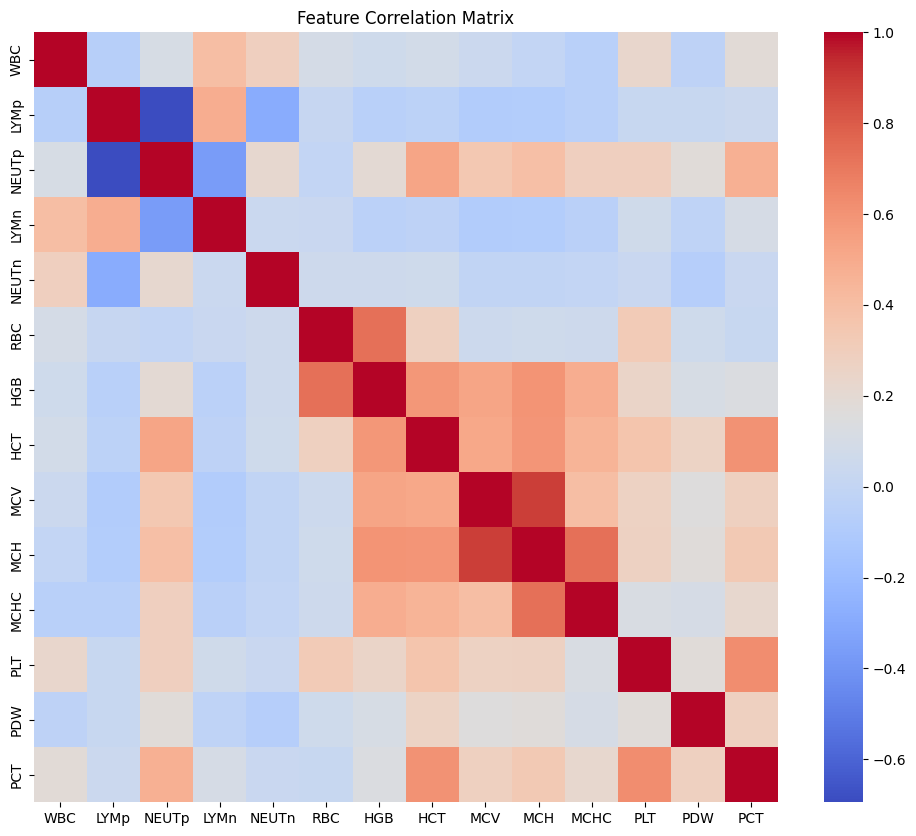

In [61]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop("Diagnosis", axis=1).corr(),
            annot=False,
            cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

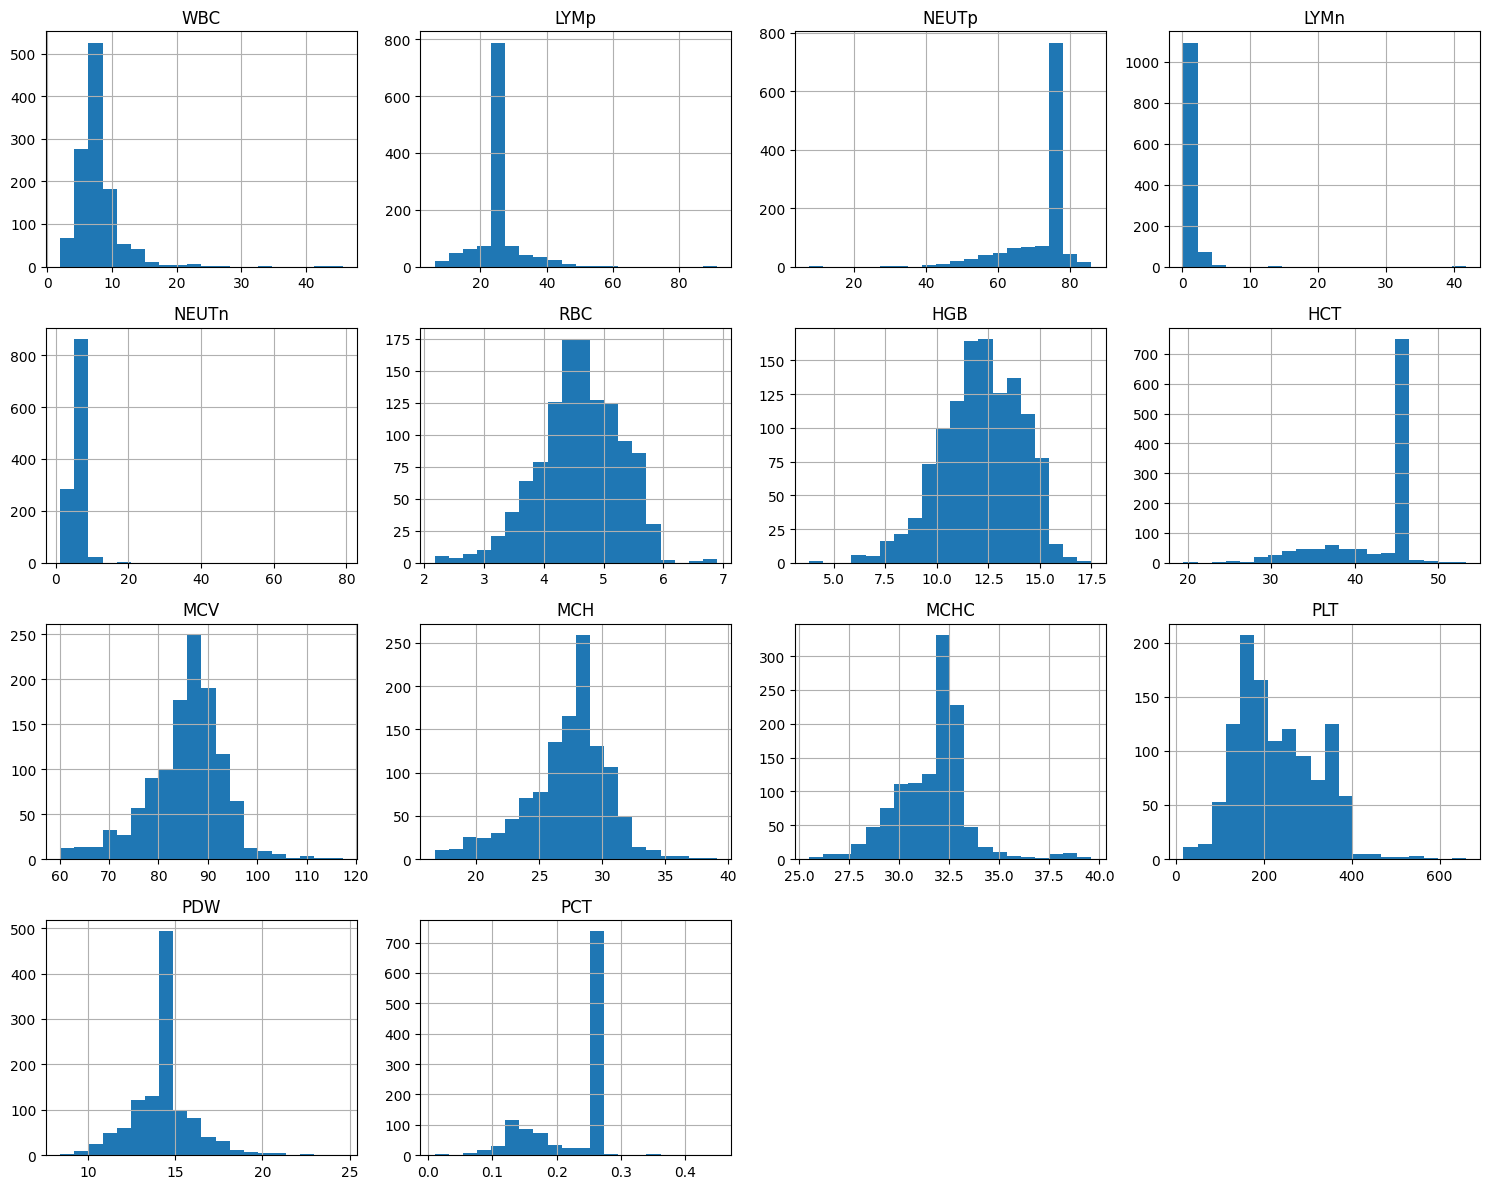

In [62]:
df.drop("Diagnosis", axis=1).hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

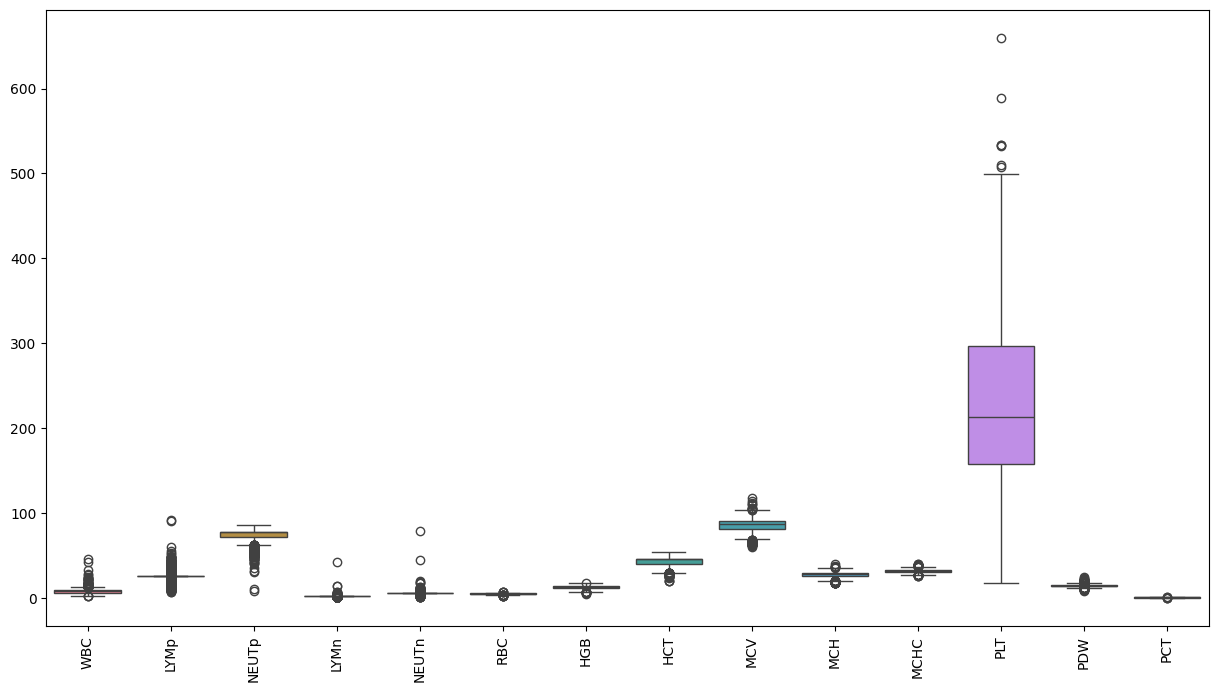

In [63]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df.drop("Diagnosis", axis=1))
plt.xticks(rotation=90)
plt.show()

# DATA PRE PROCESSING

In [64]:
X = df.drop("Diagnosis" , axis=1)
y = df["Diagnosis"]

In [65]:
le = LabelEncoder()
y = le.fit_transform(y)

In [66]:
print("Class mapping:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"{cls} → {idx}")

Class mapping:
Healthy → 0
Iron deficiency anemia → 1
Leukemia → 2
Normocytic hypochromic anemia → 3
Normocytic normochromic anemia → 4
Other anemia → 5
Thrombocytopenia → 6


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (939, 14)
Test shape: (235, 14)


In [68]:
numeric_features = X.columns

scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, numeric_features)
    ]
)

In [69]:
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))

Train class distribution: [253 134  42 209 199  48  54]
Test class distribution: [63 33 11 52 50 12 14]


In [70]:
# Random Forest (no scaling)
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

# XGBoost (no scaling)
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=len(np.unique(y)),
    random_state=42,
    use_label_encoder=False
)

# Logistic Regression (with scaling)
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=500, class_weight="balanced"))
])

# SVM (with scaling)
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, class_weight="balanced"))
])

In [71]:
estimators = [
    ("rf", rf),
    ("xgb", xgb),
    ("lr", lr_pipeline),
    ("svm", svm_pipeline)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=500),
    cv=5,
    n_jobs=-1
)

In [72]:
stack_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='mlogloss',
                                              feature...
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_class=7, ...)),
                               ('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('lr',
                                                 LogisticRegression(class_weight='balanced',
                                                                    max_iter=500))])),
                               ('svm',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('svm',
                                                 SVC(class_weight='balanced',
                                                     probability=True))]))],
                   final_estimator=LogisticRegression(max_iter=500), n_jobs=-1)

In [73]:
y_pred = stack_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9957446808510638

Classification Report:

                                precision    recall  f1-score   support

                       Healthy       1.00      1.00      1.00        63
        Iron deficiency anemia       1.00      1.00      1.00        33
                      Leukemia       0.92      1.00      0.96        11
 Normocytic hypochromic anemia       1.00      1.00      1.00        52
Normocytic normochromic anemia       1.00      0.98      0.99        50
                  Other anemia       1.00      1.00      1.00        12
              Thrombocytopenia       1.00      1.00      1.00        14

                      accuracy                           1.00       235
                     macro avg       0.99      1.00      0.99       235
                  weighted avg       1.00      1.00      1.00       235



In [74]:
# CV SCORE
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    stack_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation accuracy:", cv_scores.mean())

Cross-validation accuracy: 0.9923367885070012


In [75]:
import joblib

joblib.dump(stack_model, "hematology_stacked_model.pkl")

['hematology_stacked_model.pkl']

The dataset is highly separable because:

Leukemia → High WBC

Thrombocytopenia → Low Platelets

Iron deficiency → Low MCV + Low HGB

Normocytic anemia → Normal MCV + Low HGB

The model is learning strong CBC patterns that almost deterministically define classes.

This explains near-perfect performance.